## Phase 1 : Setup et Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    top_k_accuracy_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import warnings

warnings.filterwarnings("ignore")

# Configuration
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

## Phase 2 : Chargement et Exploration CIFAR-100

In [ ]:
# Charger CIFAR-100 (fine labels = 100 classes)
(X_train_full, y_train_fine), (X_test, y_test_fine) = cifar100.load_data(
    label_mode="fine"
)

# Charger aussi les super-classes (20 coarse labels)
(_, y_train_coarse), (_, y_test_coarse) = cifar100.load_data(label_mode="coarse")

# Flatten labels
y_train_fine = y_train_fine.flatten()
y_test_fine = y_test_fine.flatten()
y_train_coarse = y_train_coarse.flatten()
y_test_coarse = y_test_coarse.flatten()

print(f"Dataset CIFAR-100 chargé!")
print(f"Train set: {X_train_full.shape}")
print(f"Test set: {X_test.shape}")
print(f"Fine classes (100): {len(np.unique(y_train_fine))}")
print(f"Coarse classes (20): {len(np.unique(y_train_coarse))}")

# Labels fine (100 classes)
fine_labels = [
    "apple",
    "aquarium_fish",
    "baby",
    "bear",
    "beaver",
    "bed",
    "bee",
    "beetle",
    "bicycle",
    "bottle",
    "bowl",
    "boy",
    "bridge",
    "bus",
    "butterfly",
    "camel",
    "can",
    "castle",
    "caterpillar",
    "cattle",
    "chair",
    "chimpanzee",
    "clock",
    "cloud",
    "cockroach",
    "couch",
    "crab",
    "crocodile",
    "cup",
    "dinosaur",
    "dolphin",
    "elephant",
    "flatfish",
    "forest",
    "fox",
    "girl",
    "hamster",
    "house",
    "kangaroo",
    "keyboard",
    "lamp",
    "lawn_mower",
    "leopard",
    "lion",
    "lizard",
    "lobster",
    "man",
    "maple_tree",
    "motorcycle",
    "mountain",
    "mouse",
    "mushroom",
    "oak_tree",
    "orange",
    "orchid",
    "otter",
    "palm_tree",
    "pear",
    "pickup_truck",
    "pine_tree",
    "plain",
    "plate",
    "poppy",
    "porcupine",
    "possum",
    "rabbit",
    "raccoon",
    "ray",
    "road",
    "rocket",
    "rose",
    "sea",
    "seal",
    "shark",
    "shrew",
    "skunk",
    "skyscraper",
    "snail",
    "snake",
    "spider",
    "squirrel",
    "streetcar",
    "sunflower",
    "sweet_pepper",
    "table",
    "tank",
    "telephone",
    "television",
    "tiger",
    "tractor",
    "train",
    "trout",
    "tulip",
    "turtle",
    "wardrobe",
    "whale",
    "willow_tree",
    "wolf",
    "woman",
    "worm",
]

# Super-classes labels (20)
coarse_labels = [
    "aquatic_mammals",
    "fish",
    "flowers",
    "food_containers",
    "fruit_and_vegetables",
    "household_electrical_devices",
    "household_furniture",
    "insects",
    "large_carnivores",
    "large_man-made_outdoor_things",
    "large_natural_outdoor_scenes",
    "large_omnivores_and_herbivores",
    "medium_mammals",
    "non-insect_invertebrates",
    "people",
    "reptiles",
    "small_mammals",
    "trees",
    "vehicles_1",
    "vehicles_2",
]

# Distribution classes (100 classes = beaucoup!)
print(f"\nDistribution (seulement 600 images par classe):")
for i in range(10):  # Afficher seulement 10 premières
    count = (y_train_fine == i).sum()
    print(f"{fine_labels[i]:20} : {count:4}")
print("...")

Dataset CIFAR-100 chargé!
Train set: (50000, 32, 32, 3)
Test set: (10000, 32, 32, 3)
Fine classes (100): 100
Coarse classes (20): 20

Distribution (seulement 600 images par classe):
apple                :  500
aquarium_fish        :  500
baby                 :  500
bear                 :  500
beaver               :  500
bed                  :  500
bee                  :  500
beetle               :  500
bicycle              :  500
bottle               :  500
...


## Phase 3 : Exploration Visuelle

Visualisons quelques classes pour comprendre la difficulté.

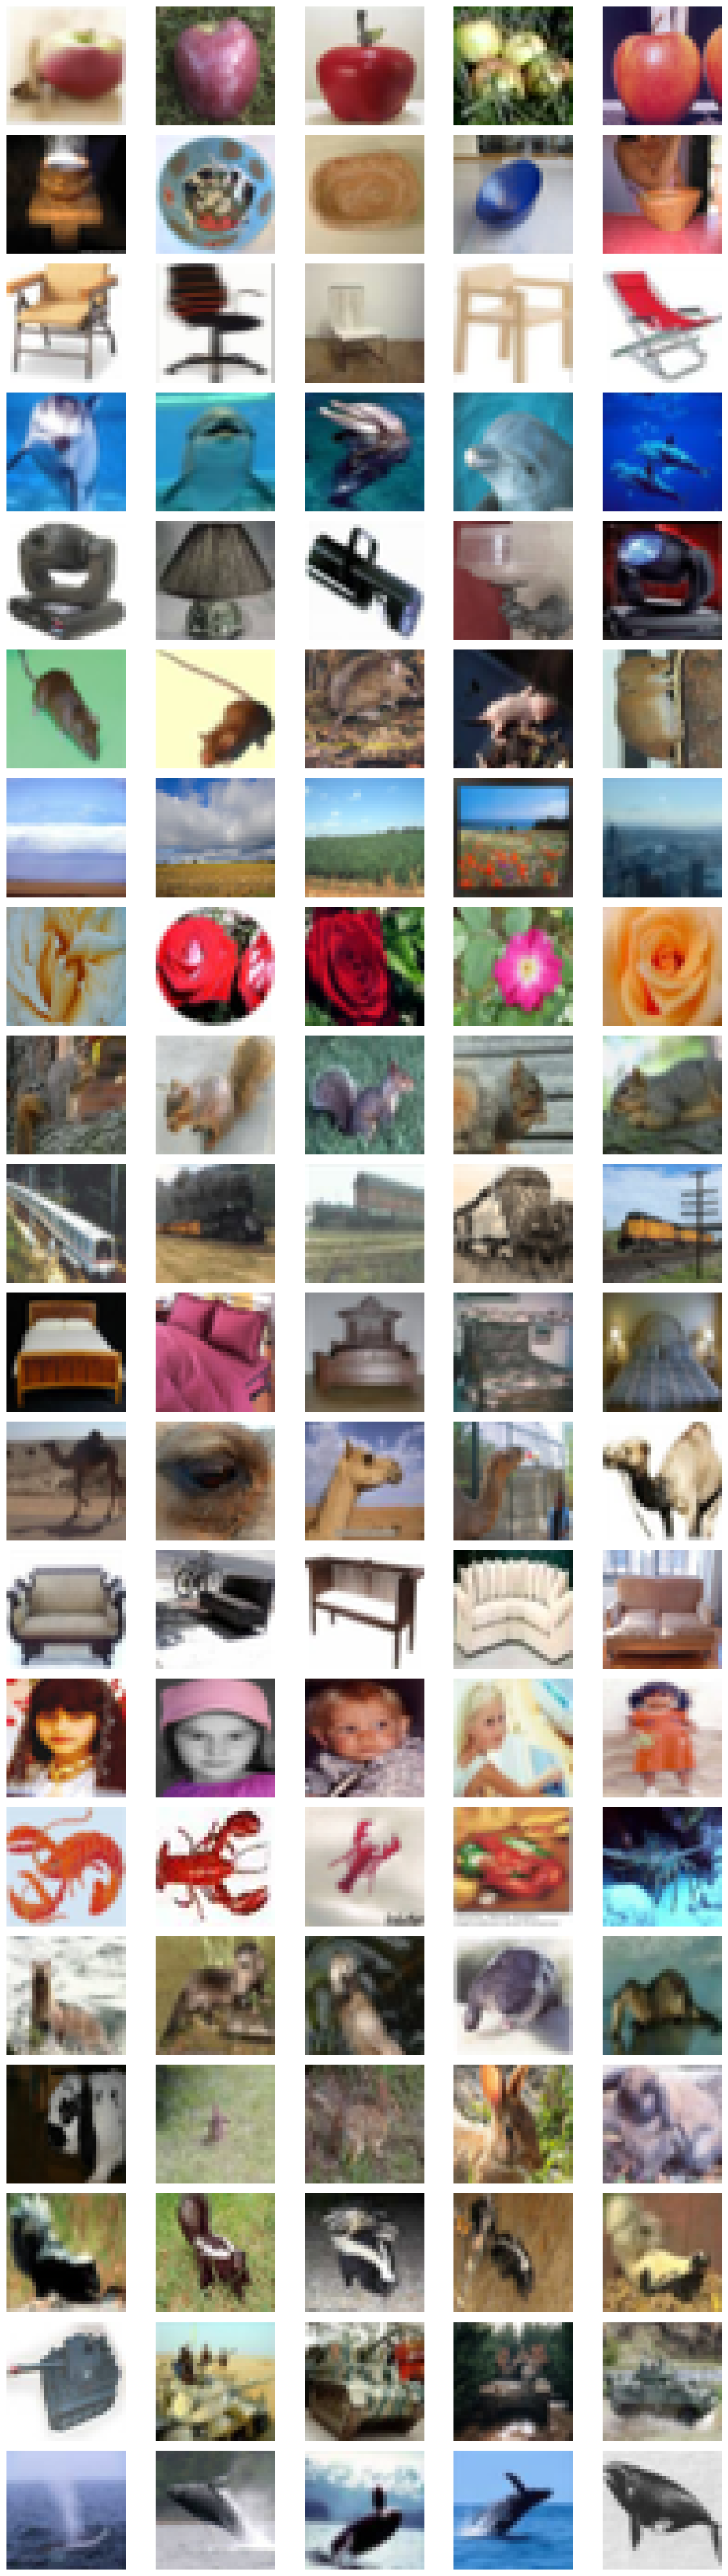

In [ ]:
# Afficher 20 classes sélectionnées (5 images par classe)
selected_classes = [
    0,
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    5,
    15,
    25,
    35,
    45,
    55,
    65,
    75,
    85,
    95,
]  # 20 classes

fig, axes = plt.subplots(20, 5, figsize=(12, 40))

for i, class_id in enumerate(selected_classes):
    # Trouver 5 images de cette classe
    indices = np.where(y_train_fine == class_id)[0][:5]

    for j, idx in enumerate(indices):
        axes[i, j].imshow(X_train_full[idx].astype("uint8"))
        if j == 0:
            axes[i, j].set_ylabel(
                fine_labels[class_id], fontsize=8, rotation=0, ha="right"
            )
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

## Phase 4 : Analyse Hiérarchique (Super-classes)

Analysons la hiérarchie 20 super-classes → 100 classes.

In [ ]:
for coarse_id in range(5):  # Afficher 5 super-classes
    # Trouver quelles classes fine appartiennent à cette coarse
    mask = y_train_coarse == coarse_id
    fine_in_coarse = np.unique(y_train_fine[mask])

    print(f"\n{coarse_labels[coarse_id]}:")
    print(
        f"  → {len(fine_in_coarse)} classes: {[fine_labels[i] for i in fine_in_coarse[:3]]}..."
    )


aquatic_mammals:
  → 5 classes: ['beaver', 'dolphin', 'otter']...

fish:
  → 5 classes: ['aquarium_fish', 'flatfish', 'ray']...

flowers:
  → 5 classes: ['orchid', 'poppy', 'rose']...

food_containers:
  → 5 classes: ['bottle', 'bowl', 'can']...

fruit_and_vegetables:
  → 5 classes: ['apple', 'mushroom', 'orange']...


In [ ]:
# Normaliser les images (0-255 → 0-1)
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Train/Validation split (90% train, 10% val)
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_full, y_train_fine, test_size=0.1, random_state=42, stratify=y_train_fine
)

print(f"Train split: {X_train_split.shape}")
print(f"Validation split: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# One-hot encode labels (100 classes)
from tensorflow.keras.utils import to_categorical

y_train_split = to_categorical(y_train_split, 100)
y_val = to_categorical(y_val, 100)
y_test_onehot = to_categorical(y_test_fine, 100)

print(f"Train labels: {y_train_split.shape}")
print(f"Val labels: {y_val.shape}")
print(f"Test labels: {y_test_onehot.shape}")

Train split: (45000, 32, 32, 3)
Validation split: (5000, 32, 32, 3)
Test set: (10000, 32, 32, 3)
Train labels: (45000, 100)
Val labels: (5000, 100)
Test labels: (10000, 100)


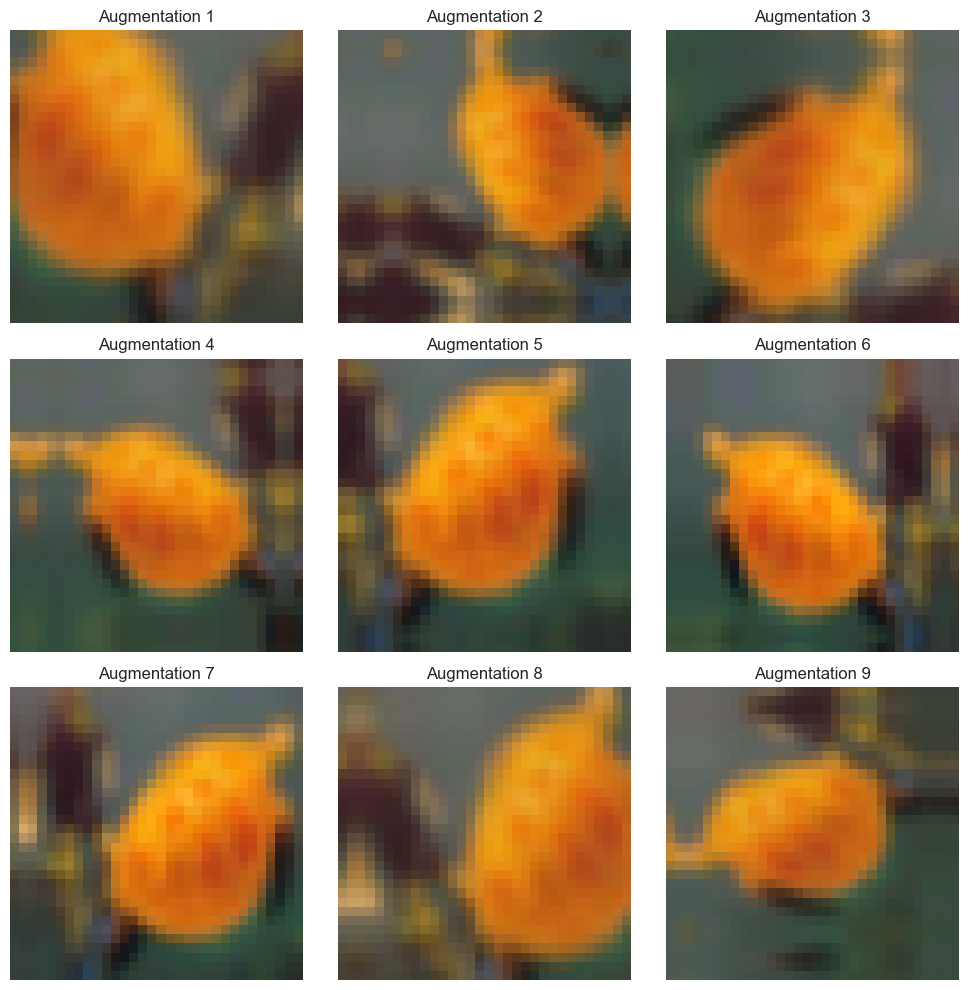

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomTranslation(0.15, 0.15),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2),
    ],
    name="data_augmentation",
)


# Afficher exemples augmentés
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

sample_idx = 0
sample_img = X_train_split[sample_idx]  # Déjà normalisé
sample_img_batch = tf.expand_dims(sample_img, 0)

for i in range(9):
    img = data_augmentation(sample_img_batch, training=True)[0]
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(f"Augmentation {i + 1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Phase 6 : Data Augmentation (ESSENTIELLE pour 600 images/classe!)

In [ ]:
# Architecture 1: CNN Simple (Baseline)
def create_cnn_simple_cifar100():
    model = models.Sequential(
        [
            # Data augmentation intégrée
            data_augmentation,
            layers.Conv2D(
                64, 3, activation="relu", padding="same", input_shape=(32, 32, 3)
            ),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.25),
            layers.Conv2D(128, 3, activation="relu", padding="same"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.3),
            layers.Conv2D(256, 3, activation="relu", padding="same"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.4),
            layers.Flatten(),
            layers.Dense(512, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(100, activation="softmax"),  # 100 classes!
        ]
    )
    return model


model_cnn = create_cnn_simple_cifar100()
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=5, name="top5_acc")],
)

model_cnn.summary()


callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        "cnn_simple_cifar100_best.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history_cnn = model_cnn.fit(
    X_train_split,
    y_train_split,
    batch_size=64,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (1, 32, 32, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (1, 32, 32, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (1, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (1, 16, 16, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (1, 16, 16, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (1, 16, 16, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (1, 8, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (1, 8, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (1, 8, 8, 256)         │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (1, 8, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (1, 4, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (1, 4, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (1, 4096)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 512)               │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (1, 512)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1, 100)               │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,521,572 (9.62 MB)

 Trainable params: 2,520,676 (9.62 MB)

 Non-trainable params: 896 (3.50 KB)

...


Epoch 1: finished saving model to cnn_simple_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - accuracy: 0.0249 - loss: 4.5364 - top5_acc: 0.1088 - val_accuracy: 0.0546 - val_loss: 4.2035 - val_top5_acc: 0.2038 - learning_rate: 0.0010
Epoch 2/5
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0369 - loss: 4.3579 - top5_acc: 0.1501
Epoch 2: val_accuracy improved from 0.05460 to 0.05800, saving model to cnn_simple_cifar100_best.h5



Epoch 2: finished saving model to cnn_simple_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.0380 - loss: 4.3314 - top5_acc: 0.1541 - val_accuracy: 0.0580 - val_loss: 4.0528 - val_top5_acc: 0.2490 - learning_rate: 0.0010
Epoch 3/5
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0422 - loss: 4.2699 - top5_acc: 0.1704
Epoch 3: val_accuracy improved from 0.05800 to 0.09580, saving model to cnn_simple_cifar100_best.h5



Epoch 3: finished saving model to cnn_simple_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.0460 - loss: 4.2472 - top5_acc: 0.1795 - val_accuracy: 0.0958 - val_loss: 3.9019 - val_top5_acc: 0.2988 - learning_rate: 0.0010
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0492 - loss: 4.1995 - top5_acc: 0.1935
Epoch 4: val_accuracy improved from 0.09580 to 0.10200, saving model to cnn_simple_cifar100_best.h5



Epoch 4: finished saving model to cnn_simple_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.0518 - loss: 4.1795 - top5_acc: 0.1995 - val_accuracy: 0.1020 - val_loss: 3.8398 - val_top5_acc: 0.3318 - learning_rate: 0.0010
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0555 - loss: 4.1395 - top5_acc: 0.2142
Epoch 5: val_accuracy improved from 0.10200 to 0.10940, saving model to cnn_simple_cifar100_best.h5



Epoch 5: finished saving model to cnn_simple_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.0582 - loss: 4.1169 - top5_acc: 0.2201 - val_accuracy: 0.1094 - val_loss: 3.8220 - val_top5_acc: 0.3290 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


## Phase 7 : Architecture 1 - CNN Simple (Baseline)

**Attention:** 100 classes rend la tâche beaucoup plus difficile!

In [ ]:
# Architecture 2: CNN Profond
def create_cnn_deep_cifar100():
    inputs = layers.Input(shape=(32, 32, 3))

    x = data_augmentation(inputs)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1024, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(100, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model


model_deep = create_cnn_deep_cifar100()
model_deep.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        "cnn_deep_cifar100_best.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history_deep = model_deep.fit(
    X_train_split,
    y_train_split,
    batch_size=64,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/5
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.0241 - loss: 4.8585
Epoch 1: val_accuracy improved from None to 0.04420, saving model to cnn_deep_cifar100_best.h5



Epoch 1: finished saving model to cnn_deep_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 117ms/step - accuracy: 0.0334 - loss: 4.5004 - val_accuracy: 0.0442 - val_loss: 4.2417 - learning_rate: 0.0010
Epoch 2/5
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.0483 - loss: 4.2086
Epoch 2: val_accuracy improved from 0.04420 to 0.08660, saving model to cnn_deep_cifar100_best.h5



Epoch 2: finished saving model to cnn_deep_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.0536 - loss: 4.1643 - val_accuracy: 0.0866 - val_loss: 3.9250 - learning_rate: 0.0010
Epoch 3/5
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.0659 - loss: 4.0852
Epoch 3: val_accuracy improved from 0.08660 to 0.09940, saving model to cnn_deep_cifar100_best.h5



Epoch 3: finished saving model to cnn_deep_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.0696 - loss: 4.0526 - val_accuracy: 0.0994 - val_loss: 3.8593 - learning_rate: 0.0010
Epoch 4/5
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.0774 - loss: 4.0013
Epoch 4: val_accuracy improved from 0.09940 to 0.12720, saving model to cnn_deep_cifar100_best.h5



Epoch 4: finished saving model to cnn_deep_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.0811 - loss: 3.9694 - val_accuracy: 0.1272 - val_loss: 3.6825 - learning_rate: 0.0010
Epoch 5/5
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.0852 - loss: 3.9275
Epoch 5: val_accuracy improved from 0.12720 to 0.13000, saving model to cnn_deep_cifar100_best.h5



Epoch 5: finished saving model to cnn_deep_cifar100_best.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.0898 - loss: 3.9073 - val_accuracy: 0.1300 - val_loss: 3.6152 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


## Phase 8 : Architecture 2 - CNN Profond

In [ ]:
def create_mobilenet_cifar100():
    # Input
    inputs = layers.Input(shape=(32, 32, 3))

    # Data augmentation
    x = data_augmentation(inputs)

    # Upscale layer
    x = layers.Resizing(96, 96)(x)

    # Base model
    base_model = MobileNetV2(
        input_shape=(96, 96, 3), include_top=False, weights="imagenet"
    )

    # Geler les couches initiales
    base_model.trainable = False

    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(100, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base_model


model_mobile, base_mobile = create_mobilenet_cifar100()
model_mobile.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        "mobilenet_cifar100_phase1.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history_mobile = model_mobile.fit(
    X_train_split,
    y_train_split,
    batch_size=32,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0791 - loss: 4.1828
Epoch 1: val_accuracy improved from None to 0.24960, saving model to mobilenet_cifar100_phase1.h5



Epoch 1: finished saving model to mobilenet_cifar100_phase1.h5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 39ms/step - accuracy: 0.1121 - loss: 3.8987 - val_accuracy: 0.2496 - val_loss: 2.9992 - learning_rate: 0.0010
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1548 - loss: 3.5841
Epoch 2: val_accuracy improved from 0.24960 to 0.29320, saving model to mobilenet_cifar100_phase1.h5



Epoch 2: finished saving model to mobilenet_cifar100_phase1.h5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.1595 - loss: 3.5476 - val_accuracy: 0.2932 - val_loss: 2.8135 - learning_rate: 0.0010
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1713 - loss: 3.4740
Epoch 3: val_accuracy did not improve from 0.29320
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 39ms/step - accuracy: 0.1787 - loss: 3.4516 - val_accuracy: 0.2890 - val_loss: 2.8907 - learning_rate: 0.0010
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1841 - loss: 3.4229
Epoch 4: val_accuracy improved from 0.29320 to 0.29940, saving model to mobilenet_cifar100_phase1.h5



Epoch 4: finished saving model to mobilenet_cifar100_phase1.h5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.1879 - loss: 3.4034 - val_accuracy: 0.2994 - val_loss: 2.7636 - learning_rate: 0.0010
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1855 - loss: 3.3946
Epoch 5: val_accuracy improved from 0.29940 to 0.31020, saving model to mobilenet_cifar100_phase1.h5



Epoch 5: finished saving model to mobilenet_cifar100_phase1.h5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.1898 - loss: 3.3701 - val_accuracy: 0.3102 - val_loss: 2.7443 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


## Phase 9 : Architecture 3 - Transfer Learning MobileNetV2

**Transfer Learning ESSENTIEL** avec seulement 600 images/classe!

In [ ]:
def create_efficientnet_cifar100():
    inputs = layers.Input(shape=(32, 32, 3))

    # Data augmentation
    x = data_augmentation(inputs)

    # Upscale
    x = layers.Resizing(224, 224)(x)

    base_model = EfficientNetB0(
        input_shape=(224, 224, 3), include_top=False, weights="imagenet"
    )

    base_model.trainable = False

    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(100, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base_model


model_efficient, base_efficient = create_efficientnet_cifar100()
model_efficient.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(
        "efficientnet_cifar100_best.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history_efficient = model_efficient.fit(
    X_train_split,
    y_train_split,
    batch_size=32,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.0081 - loss: 4.6220
Epoch 1: val_accuracy improved from None to 0.01000, saving model to efficientnet_cifar100_best.h5



Epoch 1: finished saving model to efficientnet_cifar100_best.h5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 300s 210ms/step - accuracy: 0.0084 - loss: 4.6096 - val_accuracy: 0.0100 - val_loss: 4.6052 - learning_rate: 0.0010
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.0084 - loss: 4.6058
Epoch 2: val_accuracy did not improve from 0.01000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 327s 213ms/step - accuracy: 0.0086 - loss: 4.6059 - val_accuracy: 0.0100 - val_loss: 4.6052 - learning_rate: 0.0010
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.0080 - loss: 4.6059
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.01000
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 303s 215ms/step - accuracy: 0.0082 - loss: 4.6060 - val_accuracy: 0.0100 - val_loss: 4.6052 - learning_rate: 0.0010
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.0075 - loss: 4.6057
Epoch 4: val_accuracy did not improve from 0.010

## Phase 10 : Architecture 4 - EfficientNetB0 + Fine-tuning

## Phase 11 : Évaluation et Comparaison

**Important:** Pour 100 classes, on évalue aussi **Top-5 et Top-10 accuracy**!

In [ ]:
models_dict = {
    "CNN Simple": model_cnn,
    "CNN Profond": model_deep,
    "MobileNetV2": model_mobile,
    "EfficientNetB0": model_efficient,
}

results = {}
for name, model in models_dict.items():
    print(f"\nÉvaluation {name}...")

    # Prédictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    top1_acc = (y_pred == y_test_fine).mean()

    # F1 Score
    from sklearn.metrics import f1_score

    f1 = f1_score(y_test_fine, y_pred, average="weighted")

    results[name] = {
        "top1_accuracy": top1_acc,
        "f1_score": f1,
        "y_pred": y_pred,
        "y_proba": y_pred_proba,
    }

    print(f"{name}:")
    print(f"  Top-1 Accuracy: {top1_acc:.4f} ({top1_acc * 100:.2f}%)")
    print(f"  F1 Score: {f1:.4f}")

# Tableau comparatif
comparison_df = pd.DataFrame(
    {
        "Model": list(results.keys()),
        "Top-1 Acc": [f"{results[m]['top1_accuracy'] * 100:.2f}%" for m in results],
        "F1 Score": [f"{results[m]['f1_score']:.4f}" for m in results],
    }
)


print(comparison_df.to_string(index=False))


Évaluation CNN Simple...
CNN Simple:
  Top-1 Accuracy: 0.1056 (10.56%)
  F1 Score: 0.0755

Évaluation CNN Profond...
CNN Profond:
  Top-1 Accuracy: 0.1359 (13.59%)
  F1 Score: 0.0959

Évaluation MobileNetV2...
MobileNetV2:
  Top-1 Accuracy: 0.3050 (30.50%)
  F1 Score: 0.2810

Évaluation EfficientNetB0...
EfficientNetB0:
  Top-1 Accuracy: 0.0100 (1.00%)
  F1 Score: 0.0002
         Model Top-1 Acc F1 Score
    CNN Simple    10.56%   0.0755
   CNN Profond    13.59%   0.0959
   MobileNetV2    30.50%   0.2810
EfficientNetB0     1.00%   0.0002


## Phase 12 : Visualisations Courbes d'Apprentissage

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

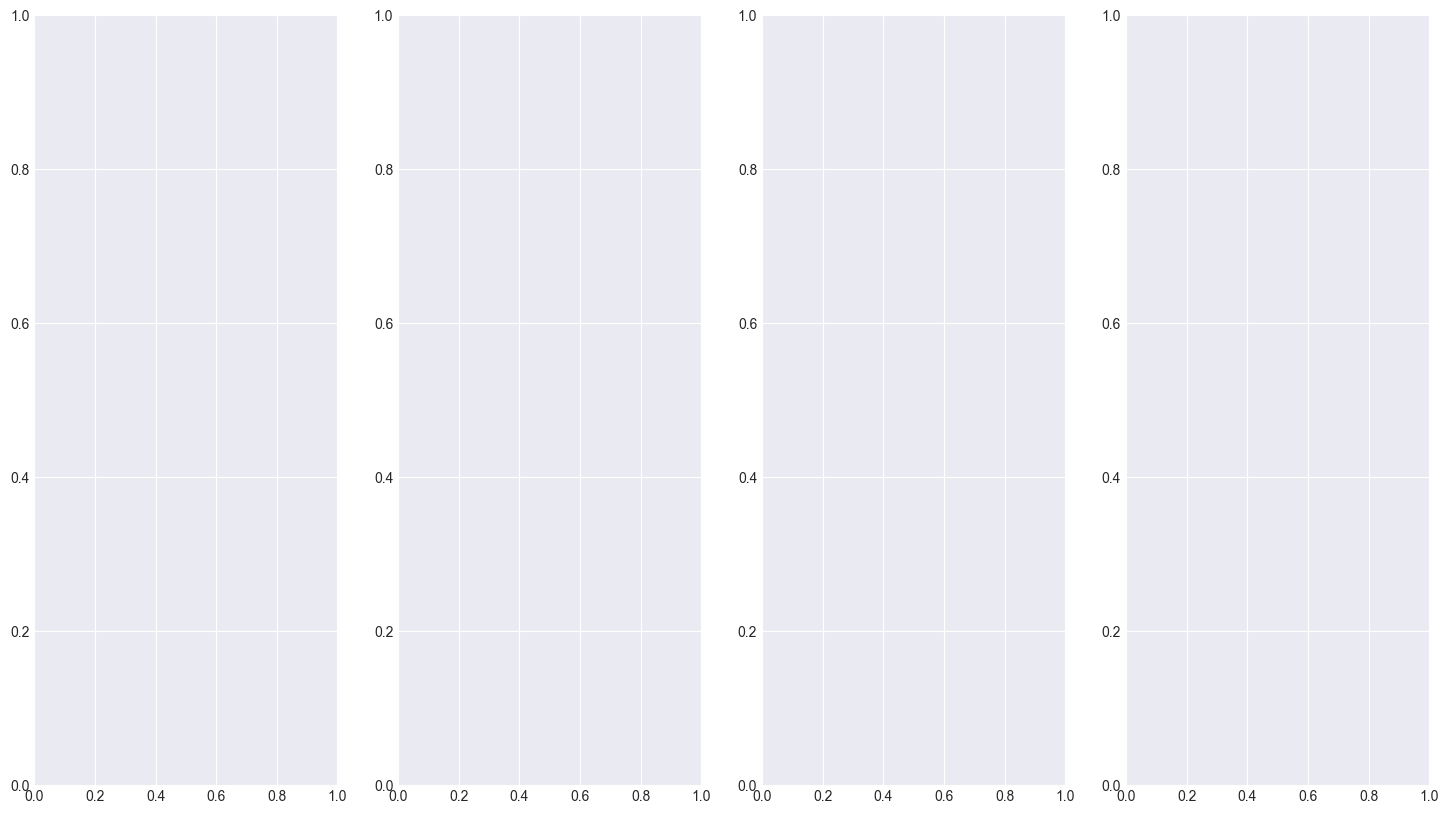

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 10))

histories = {
    "CNN Simple": history_cnn,
    "CNN Profond": history_deep,
    "MobileNetV2": history_mobile,
    "EfficientNetB0": history_efficient,
}

for idx, (name, hist) in enumerate(histories.items()):
    # Top-1 Accuracy
    axes[0, idx].plot(hist.history["accuracy"], label="Train")
    axes[0, idx].plot(hist.history["val_accuracy"], label="Val")
    axes[0, idx].set_title(f"{name} - Top-1 Accuracy")
    axes[0, idx].set_xlabel("Epoch")
    axes[0, idx].set_ylabel("Accuracy")
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

## Phase 13 : Analyse par Classe (100 classes!)

Identifions les classes faciles et difficiles.

In [ ]:
# Sélectionner meilleur modèle
best_model_name = max(results, key=lambda x: results[x]["top1_accuracy"])
best_model = models_dict[best_model_name]
y_pred_best = results[best_model_name]["y_pred"]

print(f"Meilleur modèle: {best_model_name}")
print(f"Top-1: {results[best_model_name]['top1_accuracy'] * 100:.2f}%")

class_accuracies = []
for i in range(100):
    mask = y_test_fine == i
    if mask.sum() > 0:
        acc = (y_pred_best[mask] == y_test_fine[mask]).mean()
        class_accuracies.append((fine_labels[i], acc, i))

class_accuracies.sort(key=lambda x: x[1], reverse=True)

print("CLASSES LES PLUS FACILES")
for i, (name, acc, idx) in enumerate(class_accuracies[:10]):
    print(f"{i + 1}. {name:20} : {acc * 100:.2f}%")

print("CLASSES LES PLUS DIFFICILES")
for i, (name, acc, idx) in enumerate(class_accuracies[-10:]):
    print(f"{i + 1}. {name:20} : {acc * 100:.2f}%")

Meilleur modèle: MobileNetV2
Top-1: 31.31%
Top-5: 62.43%

=== TOP 10 CLASSES LES PLUS FACILES ===
1. motorcycle           : 91.00%
2. chair                : 90.00%
3. sunflower            : 82.00%
4. orange               : 76.00%
5. wardrobe             : 76.00%
6. cloud                : 70.00%
7. worm                 : 66.00%
8. keyboard             : 65.00%
9. television           : 65.00%
10. pickup_truck         : 64.00%

=== TOP 10 CLASSES LES PLUS DIFFICILES ===
1. table                : 4.00%
2. seal                 : 3.00%
3. crocodile            : 2.00%
4. otter                : 2.00%
5. house                : 1.00%
6. couch                : 0.00%
7. girl                 : 0.00%
8. kangaroo             : 0.00%
9. rabbit               : 0.00%
10. squirrel             : 0.00%


## Phase 14 : Confusion Matrix (Top 20 classes)

100 classes = trop pour visualiser. Analysons les 20 plus fréquentes.


=== TOP 10 CONFUSIONS ===
1. bicycle              → motorcycle           :  43 erreurs
2. fox                  → tiger                :  40 erreurs
3. dolphin              → whale                :  35 erreurs
4. bed                  → chair                :  34 erreurs
5. couch                → chair                :  31 erreurs
6. maple_tree           → oak_tree             :  31 erreurs
7. streetcar            → bus                  :  31 erreurs
8. bus                  → pickup_truck         :  29 erreurs
9. lawn_mower           → motorcycle           :  28 erreurs
10. table                → chair                :  28 erreurs


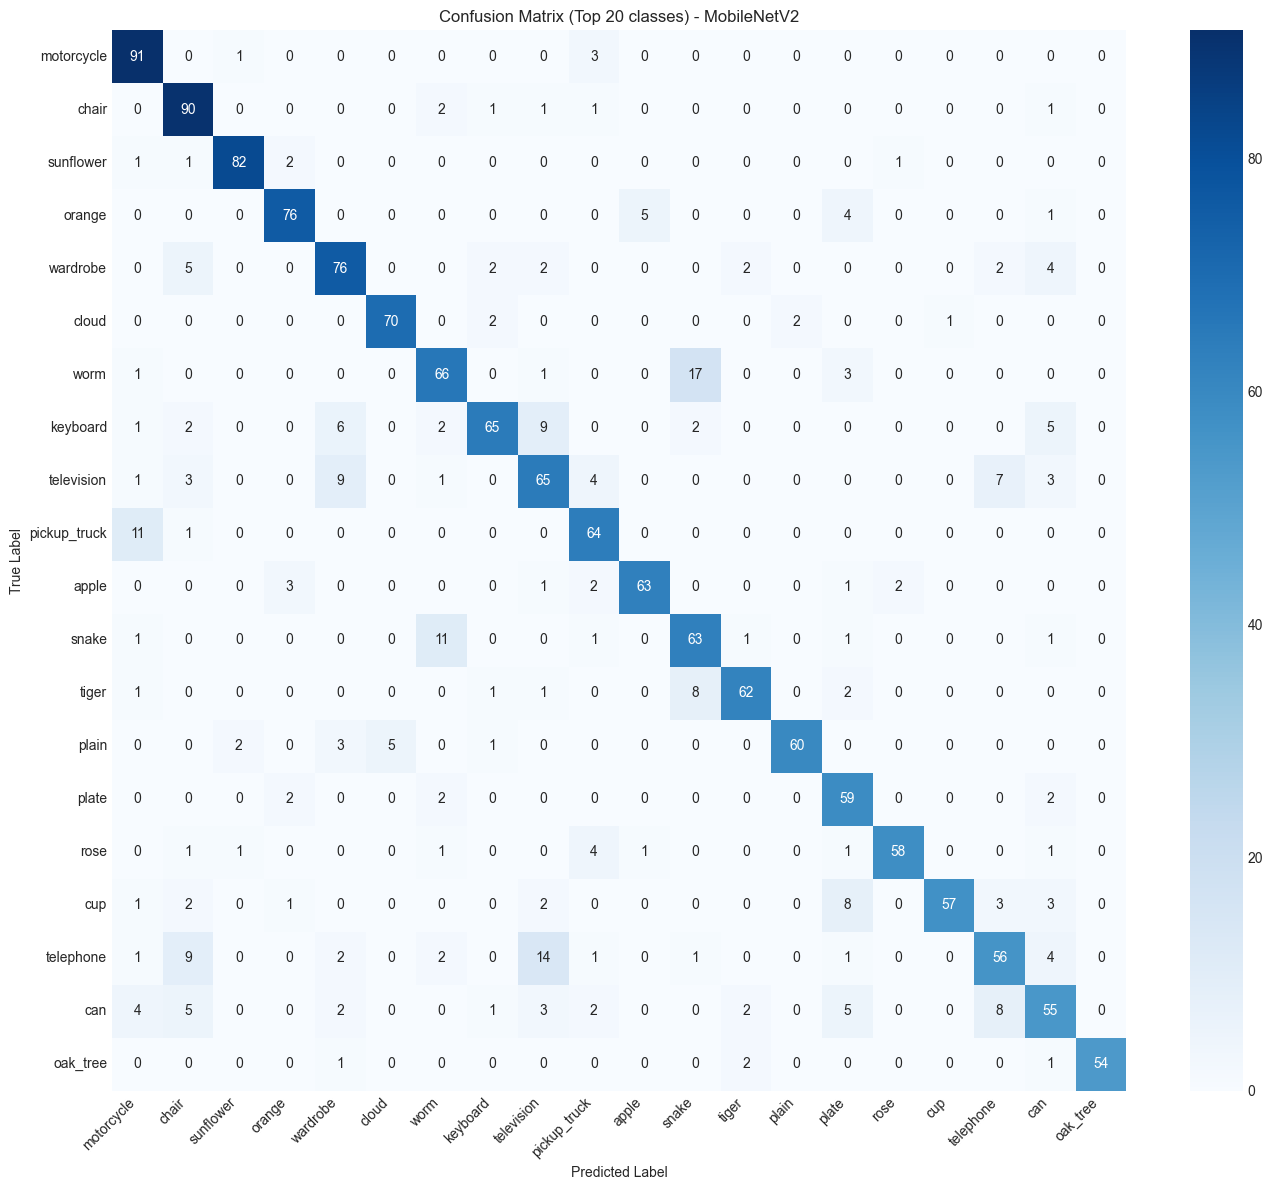

In [ ]:
cm = confusion_matrix(y_test_fine, y_pred_best)

np.fill_diagonal(cm, 0)
top_confusions = []
for i in range(100):
    for j in range(100):
        if i != j and cm[i, j] > 0:
            top_confusions.append((fine_labels[i], fine_labels[j], cm[i, j]))

top_confusions.sort(key=lambda x: x[2], reverse=True)

print("TOP 10 CONFUSIONS")
for i, (c1, c2, count) in enumerate(top_confusions[:10]):
    print(f"{i + 1}. {c1:20} → {c2:20} : {count:3} erreurs")

# Visualiser top 20 classes
top20_indices = [acc[2] for acc in class_accuracies[:20]]
cm_full = confusion_matrix(y_test_fine, y_pred_best)
cm_top20 = cm_full[np.ix_(top20_indices, top20_indices)]
top20_labels = [fine_labels[i] for i in top20_indices]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_top20,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=top20_labels,
    yticklabels=top20_labels,
)
plt.title(f"Confusion Matrix (Top 20 classes) - {best_model_name}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Phase 15 : Sauvegarde et Conclusions

In [ ]:
# Sauvegarder le meilleur modèle
best_model.save("best_cifar100_model.h5")

# Sauvegarder métadonnées
import json
from datetime import datetime

metadata = {
    "model": best_model_name,
    "dataset": "CIFAR-100",
    "num_classes": 100,
    "top1_accuracy": float(results[best_model_name]["top1_accuracy"]),
    "f1_score": float(results[best_model_name]["f1_score"]),
    "created_at": datetime.now().isoformat(),
}

with open("cifar100_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Modèle {best_model_name} sauvegardé!")
print(json.dumps(metadata, indent=2))

NameError: name 'best_model' is not defined